In [28]:
# -----------------------------
# Imports
# -----------------------------

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import cmocean.cm as cm

Next, define the location of the input directory for the model. This is the same directory that holds the bathymetry file generated in the previous notebooks for this model example.

In [29]:
# -----------------------------
# File paths
# -----------------------------

# Folder where model input files are stored
input_dir = r"C:\Users\rilee\MS 274\Final_Project\input"

# External forcing source files
exf_station_file = "slough_exf_vars.csv"
wind_file = "slough_wind.csv"

# Output folder for EXF binary files
exf_output_dir = os.path.join(input_dir, "exf")
os.makedirs(exf_output_dir, exist_ok=True)

print("Input directory:", input_dir)
print("EXF output directory:", exf_output_dir)

Input directory: C:\Users\rilee\MS 274\Final_Project\input
EXF output directory: C:\Users\rilee\MS 274\Final_Project\input\exf


### Step 2: Read in the Model grid

To read in the model fields, I will rely on the grid parameters from the grid file:

In [30]:
# -----------------------------
# Recreate model grid
# -----------------------------

xgOrigin = -121.795
ygOrigin = 36.8

Nx = 360
Ny = 240
Nr = 5

delX = 0.0001555555555555483
delY = 0.00025416666666666643

rxc = xgOrigin + (np.arange(Nx) + 0.5) * delX
ryc = ygOrigin + (np.arange(Ny) + 0.5) * delY

XC, YC = np.meshgrid(rxc, ryc)

print("XC shape:", XC.shape)
print("YC shape:", YC.shape)

# -----------------------------
# Read final MITgcm bathymetry
# -----------------------------

bathy_file = os.path.join(input_dir, "slough_bathymetry.bin")

bathy = np.fromfile(bathy_file, dtype=">f4").reshape((Ny, Nx))

print("bathy shape:", bathy.shape)
print("NaN count:", np.isnan(bathy).sum())
print("min/max:", np.nanmin(bathy), np.nanmax(bathy))
print("wet cells:", np.sum(bathy < 0))
print("land cells:", np.sum(bathy == 0))
print("positive bad cells:", np.sum(bathy > 0))

XC shape: (240, 360)
YC shape: (240, 360)
bathy shape: (240, 360)
NaN count: 0
min/max: -29.71549 0.0
wet cells: 6399
land cells: 80001
positive bad cells: 0


With an eye toward the interpolation to come next, I will make a mask to determine where the interpolatation will take place. 

In [31]:
# -----------------------------
# Create depth and wet masks
# -----------------------------

# MITgcm bathymetry convention:
#   bathy < 0 means water depth below sea level
#   bathy = 0 means land
#
# For EXF fields:
#   water cells receive forcing values
#   land cells are set to 0

bathy_pd = np.where(bathy < 0, -bathy, 0.0)

mask2d = (bathy_pd > 0).astype(np.float32)

print("mask2d shape:", mask2d.shape)
print("wet cells:", np.sum(mask2d == 1))
print("land cells:", np.sum(mask2d == 0))
print("unique mask values:", np.unique(mask2d))

mask2d shape: (240, 360)
wet cells: 6399
land cells: 80001
unique mask values: [0. 1.]


To double check the mask was created as expected, I will plot it in comparison to the bathymetry here:

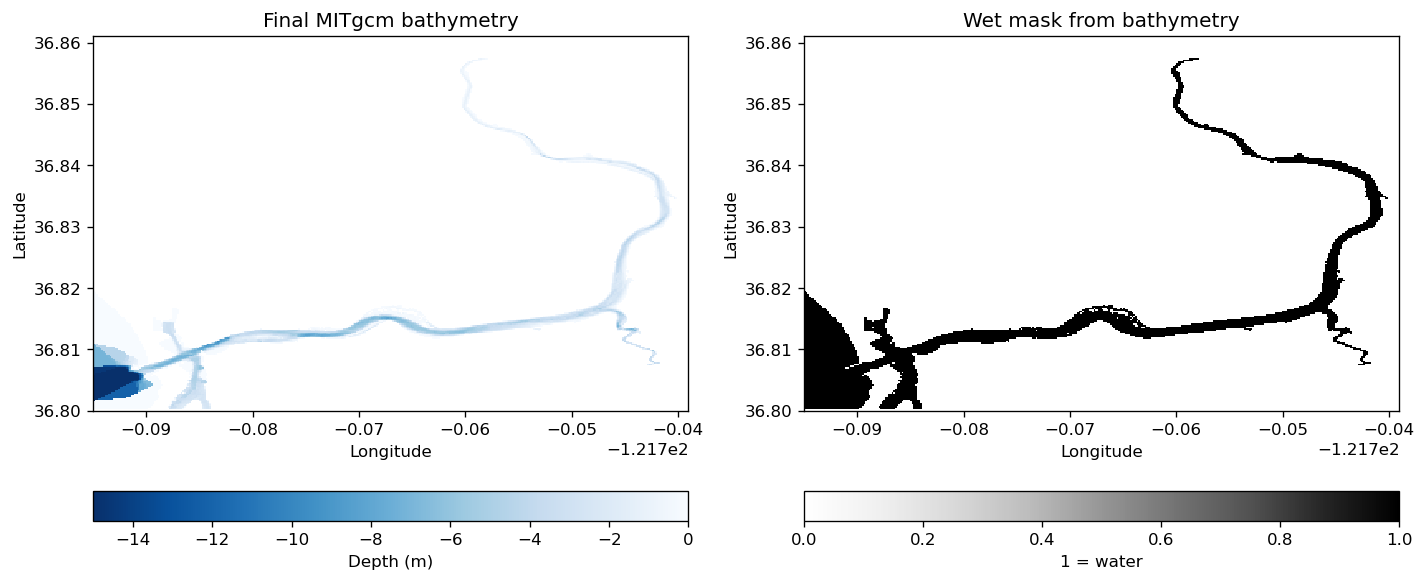

In [32]:
# -----------------------------
# Plot bathymetry and wet mask
# -----------------------------

bathy_plot = np.ma.masked_where(bathy == 0, bathy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

cmap_bathy = plt.get_cmap("Blues_r").copy()
cmap_bathy.set_bad("white")

im0 = axes[0].pcolormesh(
    XC, YC, bathy_plot,
    shading="auto",
    cmap=cmap_bathy,
    vmin=-15,
    vmax=0
)
fig.colorbar(im0, ax=axes[0], orientation="horizontal", label="Depth (m)")
axes[0].set_title("Final MITgcm bathymetry")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

im1 = axes[1].pcolormesh(
    XC, YC, mask2d,
    shading="auto",
    cmap="Greys",
    vmin=0,
    vmax=1
)
fig.colorbar(im1, ax=axes[1], orientation="horizontal", label="1 = water")
axes[1].set_title("Wet mask from bathymetry")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

Now let's read in the wind speed data and other external forcing fields

##### Step 4: Read in External Forcing Fields (ATEMP, AQH, PRECIP, TOTPAR, TOTSORAD)

In [33]:
# -----------------------------
# Read atmospheric forcing data
# -----------------------------

exf_vars = pd.read_csv(
    exf_station_file,
    header=0,
    parse_dates=["DateTimeStamp"]
)

exf_vars["DateTimeStamp"] = pd.to_datetime(exf_vars["DateTimeStamp"], errors="coerce")
exf_vars = exf_vars.set_index("DateTimeStamp")

print("Columns:")
print(exf_vars.columns.tolist())

print("Date range:")
print(exf_vars.index.min(), "to", exf_vars.index.max())

exf_vars.head()

Columns:
['StationCode', 'isSWMP', 'F_Record', 'ATemp', 'F_ATemp', 'RH', 'F_RH', 'BP', 'F_BP', 'TotPAR', 'F_TotPAR', 'TotPrcp', 'F_TotPrcp', 'TotSoRad', 'F_TotSoRad']
Date range:
2024-10-01 00:00:00 to 2025-10-01 23:45:00


C:\Users\rilee\AppData\Local\Temp\ipykernel_10184\394276665.py:5: DtypeWarning: Columns (4,6) have mixed types. Specify dtype option on import or set low_memory=False.
  exf_vars = pd.read_csv(


,StationCode,isSWMP,F_Record,ATemp,F_ATemp,RH,F_RH,BP,F_BP,TotPAR,F_TotPAR,TotPrcp,F_TotPrcp,TotSoRad,F_TotSoRad
DateTimeStamp,,,,,,,,,,,,,,,
2024-10-01 00:00:00,elkcwmet,P,NaN,16.8,<0>,80,<0>,1010.0,<0>,0.0,<0>,0.0,<0>,NaN,<-1>
2024-10-01 00:15:00,elkcwmet,P,NaN,17.1,<0>,73,<0>,1010.0,<0>,0.0,<0>,0.0,<0>,NaN,<-1>
2024-10-01 00:30:00,elkcwmet,P,NaN,16.8,<0>,73,<0>,1010.0,<0>,0.0,<0>,0.0,<0>,NaN,<-1>
2024-10-01 00:45:00,elkcwmet,P,NaN,16.8,<0>,74,<0>,1010.0,<0>,0.0,<0>,0.0,<0>,NaN,<-1>
2024-10-01 01:00:00,elkcwmet,P,NaN,17.2,<0>,68,<0>,1010.0,<0>,0.0,<0>,0.0,<0>,NaN,<-1>


In [34]:
# -----------------------------
# Compute daily means for non-wind EXF variables
# -----------------------------

raw_var_list = ["ATemp", "RH", "TotPAR", "TotPrcp", "TotSoRad"]

daily_means = pd.DataFrame()

for var in raw_var_list:
    exf_vars[var] = pd.to_numeric(exf_vars[var], errors="coerce")
    daily_means[var] = exf_vars[var].resample("D").mean()

print("Daily means shape:", daily_means.shape)
print("Year:", daily_means.index[0].year)
daily_means.head()

Daily means shape: (366, 5)
Year: 2024


,ATemp,RH,TotPAR,TotPrcp,TotSoRad
DateTimeStamp,,,,,
2024-10-01,19.905208,63.468750,383.668750,0.0,NaN
2024-10-02,18.937500,73.156250,384.908333,0.0,NaN
2024-10-03,18.888542,70.239583,390.877083,0.0,NaN
2024-10-04,15.941667,86.416667,346.040625,0.0,NaN
2024-10-05,16.054167,88.052083,381.164583,0.0,NaN


In [35]:
# -----------------------------
# Check missing values in daily means
# -----------------------------

for var in raw_var_list:
    print(
        var,
        "NaNs:", daily_means[var].isna().sum(),
        "min:", daily_means[var].min(),
        "max:", daily_means[var].max()
    )

ATemp NaNs: 3 min: -22.395714285714288 max: 19.905208333333334
RH NaNs: 3 min: 19.577464788732396 max: 95.89583333333333
TotPAR NaNs: 3 min: 51.07604166666667 max: 688.9037735849057
TotPrcp NaNs: 3 min: 0.0 max: 0.5854166666666667
TotSoRad NaNs: 366 min: nan max: nan


##### Read in Wind Data

In [36]:
# -----------------------------
# Read wind data
# -----------------------------

df = pd.read_csv(
    wind_file,
    parse_dates=["DateTimeStamp"]
)

df["DateTimeStamp"] = pd.to_datetime(df["DateTimeStamp"], errors="coerce")
df = df.set_index("DateTimeStamp")

df["WSpd"] = pd.to_numeric(df["WSpd"], errors="coerce")
df["Wdir"] = pd.to_numeric(df["Wdir"], errors="coerce")

print("Wind data date range:")
print(df.index.min(), "to", df.index.max())

df.head()

Wind data date range:
2024-10-01 00:00:00 to 2025-10-01 23:45:00


,StationCode,isSWMP,WSpd,F_WSpd,Wdir,F_Wdir
DateTimeStamp,,,,,,
2024-10-01,elkcwmet,P,0.9,<0>,185.0,<0>
2024-10-01,elkapwq,P,NaN,NaN,NaN,NaN
2024-10-01,elknmwq,P,NaN,NaN,NaN,NaN
2024-10-01,elksmwq,P,NaN,NaN,NaN,NaN
2024-10-01,elkvmwq,P,NaN,NaN,NaN,NaN


In [37]:
# -----------------------------
# Convert wind speed/direction to u/v components
# -----------------------------
# Convention used here:
#   Wdir is wind direction in degrees.
#   u is east-west wind component.
#   v is north-south wind component.
#
# The negative signs follow meteorological convention:
# wind direction is where the wind comes FROM.

theta = np.deg2rad(df["Wdir"])

df["u"] = -df["WSpd"] * np.sin(theta)
df["v"] = -df["WSpd"] * np.cos(theta)

# Daily means
ws_daily = df["WSpd"].resample("D").mean()
u_daily = df["u"].resample("D").mean()
v_daily = df["v"].resample("D").mean()

print("Wind daily timesteps:", len(ws_daily))
print("Wind year:", ws_daily.index[0].year)

print("WSpd min/max:", ws_daily.min(), ws_daily.max())
print("u min/max:", u_daily.min(), u_daily.max())
print("v min/max:", v_daily.min(), v_daily.max())

Wind daily timesteps: 366
Wind year: 2024
WSpd min/max: 0.86875 6.547916666666667
u min/max: -4.412776779818212 4.299111570490516
v min/max: -2.232016052406173 5.933666059585275


#### Interpolate and make EXF Grids!

In [38]:
# -----------------------------
# Helper functions for EXF fields
# -----------------------------

def relative_humidity_to_specific_humidity(rh_percent, temp_c, pressure_hpa=1013.25):
    """
    Convert relative humidity (%) and air temperature (°C) to specific humidity (kg/kg).

    MITgcm's aqhfile expects atmospheric specific humidity, not relative humidity.
    This conversion uses a standard saturation vapor pressure approximation.

    Parameters
    ----------
    rh_percent : array-like
        Relative humidity in percent.
    temp_c : array-like
        Air temperature in degrees Celsius.
    pressure_hpa : float
        Atmospheric pressure in hPa. A constant sea-level value is used here.

    Returns
    -------
    q : array-like
        Specific humidity in kg/kg.
    """

    rh = np.asarray(rh_percent, dtype=float)
    temp_c = np.asarray(temp_c, dtype=float)

    # Saturation vapor pressure over water, hPa
    es = 6.112 * np.exp((17.67 * temp_c) / (temp_c + 243.5))

    # Actual vapor pressure, hPa
    e = (rh / 100.0) * es

    # Specific humidity, kg/kg
    q = 0.622 * e / (pressure_hpa - 0.378 * e)

    return q


def clean_exf_grid(arr, fill_value=0.0, vmin=None, vmax=None):
    """
    Replace non-finite values and clip to broad physical limits.
    """

    arr = np.asarray(arr, dtype=np.float32)
    arr = np.where(np.isfinite(arr), arr, fill_value)

    if vmin is not None or vmax is not None:
        arr = np.clip(arr, vmin, vmax)

    return arr


def save_exf_binary(arr, output_file):
    """
    Save EXF field as big-endian float32 in C order.
    Expected shape is (time, Ny, Nx).
    """

    arr = np.asarray(arr, dtype=np.float32)
    arr.ravel(order="C").astype(">f4").tofile(output_file)

In [39]:
# -----------------------------
# Create non-wind EXF fields
# -----------------------------
# Each daily time series is expanded into a spatial grid.
# Since the available atmospheric data are station/time series values,
# each daily value is applied uniformly over water cells and set to 0 over land.

ntime = len(daily_means)
year = daily_means.index[0].year
nrows, ncols = XC.shape

# Output names expected by MITgcm/data.exf
# Raw variable -> output filename variable
output_name_map = {
    "ATemp": "ATEMP",
    "RH": "AQH",
    "TotPrcp": "PRECIP",
    "TotSoRad": "TotSoRad",
    "TotPAR": "TotPAR",
}

# Air temperature in Celsius is needed for RH -> specific humidity conversion
air_temp_c = daily_means["ATemp"].to_numpy(dtype=float)

for raw_var in raw_var_list:
    print(f"\nGenerating EXF field for {raw_var} with {ntime} timesteps")

    output_var = output_name_map[raw_var]

    # Start with daily time series
    if raw_var == "ATemp":
        # Convert Celsius to Kelvin for MITgcm atempfile
        data = daily_means[raw_var].to_numpy(dtype=float) + 273.15

        fill_value = 285.0
        vmin, vmax = 250.0, 320.0

    elif raw_var == "RH":
        # Convert relative humidity (%) to specific humidity (kg/kg)
        rh = daily_means["RH"].to_numpy(dtype=float)
        data = relative_humidity_to_specific_humidity(rh, air_temp_c)

        fill_value = 0.010
        vmin, vmax = 0.0, 0.04

    elif raw_var == "TotPrcp":
        # ASSUMPTION:
        # If TotPrcp is in mm/day, convert to m/s.
        # If your source is already m/s, remove this conversion.
        data = daily_means[raw_var].to_numpy(dtype=float) / 1000.0 / 86400.0

        fill_value = 0.0
        vmin, vmax = 0.0, 1e-4

    elif raw_var in ["TotSoRad", "TotPAR"]:
        # Shortwave/PAR radiation in W/m^2
        data = daily_means[raw_var].to_numpy(dtype=float)

        fill_value = 0.0
        vmin, vmax = 0.0, 1200.0

    else:
        data = daily_means[raw_var].to_numpy(dtype=float)

        fill_value = 0.0
        vmin, vmax = None, None

    # Expand daily values onto model grid
    exf_grid = np.zeros((ntime, nrows, ncols), dtype=np.float32)

    for t in range(ntime):
        exf_grid[t, :, :] = data[t] * mask2d

    # Clean bad values
    exf_grid = clean_exf_grid(
        exf_grid,
        fill_value=fill_value,
        vmin=vmin,
        vmax=vmax
    )

    output_file = os.path.join(exf_output_dir, f"{output_var}_{year}")
    save_exf_binary(exf_grid, output_file)

    print(
        "Saved:", output_file,
        "shape:", exf_grid.shape,
        "nan:", np.isnan(exf_grid).sum(),
        "min:", np.nanmin(exf_grid),
        "max:", np.nanmax(exf_grid)
    )


Generating EXF field for ATemp with 366 timesteps
Saved: C:\Users\rilee\MS 274\Final_Project\input\exf\ATEMP_2024 shape: (366, 240, 360) nan: 0 min: 250.0 max: 293.0552

Generating EXF field for RH with 366 timesteps
Saved: C:\Users\rilee\MS 274\Final_Project\input\exf\AQH_2024 shape: (366, 240, 360) nan: 0 min: 0.0 max: 0.012161478

Generating EXF field for TotPAR with 366 timesteps
Saved: C:\Users\rilee\MS 274\Final_Project\input\exf\TotPAR_2024 shape: (366, 240, 360) nan: 0 min: 0.0 max: 688.90375

Generating EXF field for TotPrcp with 366 timesteps
Saved: C:\Users\rilee\MS 274\Final_Project\input\exf\PRECIP_2024 shape: (366, 240, 360) nan: 0 min: 0.0 max: 6.775656e-09

Generating EXF field for TotSoRad with 366 timesteps
Saved: C:\Users\rilee\MS 274\Final_Project\input\exf\TotSoRad_2024 shape: (366, 240, 360) nan: 0 min: 0.0 max: 0.0


In [40]:
# -----------------------------
# Create wind EXF fields
# -----------------------------
# Wind speed and u/v components are applied uniformly over water cells
# and set to 0 over land.

ws = ws_daily.to_numpy(dtype=float)
u = u_daily.to_numpy(dtype=float)
v = v_daily.to_numpy(dtype=float)

ntime_wind = len(ws)
year_wind = ws_daily.index[0].year

if ntime_wind != ntime:
    print("Warning: wind and non-wind EXF have different number of timesteps")
    print("non-wind ntime:", ntime)
    print("wind ntime:", ntime_wind)

def make_spatial_exf_from_timeseries(series, mask2d):
    out = np.zeros((len(series), mask2d.shape[0], mask2d.shape[1]), dtype=np.float32)

    for t in range(len(series)):
        out[t, :, :] = series[t] * mask2d

    return out


interpolated_ws = make_spatial_exf_from_timeseries(ws, mask2d)
interpolated_u = make_spatial_exf_from_timeseries(u, mask2d)
interpolated_v = make_spatial_exf_from_timeseries(v, mask2d)

# Clean wind fields
interpolated_ws = clean_exf_grid(interpolated_ws, fill_value=0.0, vmin=0.0, vmax=50.0)
interpolated_u = clean_exf_grid(interpolated_u, fill_value=0.0, vmin=-50.0, vmax=50.0)
interpolated_v = clean_exf_grid(interpolated_v, fill_value=0.0, vmin=-50.0, vmax=50.0)

wind_outputs = {
    f"WDSPD_{year_wind}": interpolated_ws,
    f"UWIND_{year_wind}": interpolated_u,
    f"VWIND_{year_wind}": interpolated_v,
}

for fname, arr in wind_outputs.items():
    output_file = os.path.join(exf_output_dir, fname)
    save_exf_binary(arr, output_file)

    print(
        "Saved:", output_file,
        "shape:", arr.shape,
        "nan:", np.isnan(arr).sum(),
        "min:", np.nanmin(arr),
        "max:", np.nanmax(arr)
    )

Saved: C:\Users\rilee\MS 274\Final_Project\input\exf\WDSPD_2024 shape: (366, 240, 360) nan: 0 min: 0.0 max: 6.547917
Saved: C:\Users\rilee\MS 274\Final_Project\input\exf\UWIND_2024 shape: (366, 240, 360) nan: 0 min: -4.412777 max: 4.2991114
Saved: C:\Users\rilee\MS 274\Final_Project\input\exf\VWIND_2024 shape: (366, 240, 360) nan: 0 min: -2.232016 max: 5.933666


#### Plot the External Forcing Fields

In [41]:
# -----------------------------
# Plot metadata for EXF fields
# -----------------------------

plot_meta = {
    "ATEMP":    (250, 320, cm.thermal, "K"),
    "AQH":      (0, 0.025, cm.tempo, "kg/kg"),
    "PRECIP":   (0, 1e-7, cm.tempo, "m/s"),
    "TotPAR":   (0, 700, cm.solar, "W/m²"),
    "TotSoRad": (0, 700, cm.solar, "W/m²"),
    "WDSPD":    (0, 8, "viridis", "m/s"),
    "UWIND":    (-8, 8, "seismic", "m/s"),
    "VWIND":    (-8, 8, "seismic", "m/s"),
}

In [42]:
# -----------------------------
# Check EXF binary file sizes and values
# -----------------------------

expected_nt = ntime
expected_size = expected_nt * Ny * Nx

exf_files_to_check = [
    "ATEMP_2024",
    "AQH_2024",
    "PRECIP_2024",
    "TotPAR_2024",
    "TotSoRad_2024",
    "WDSPD_2024",
    "UWIND_2024",
    "VWIND_2024",
]

for fname in exf_files_to_check:
    path = os.path.join(exf_output_dir, fname)

    if not os.path.exists(path):
        print("MISSING:", fname)
        continue

    arr = np.fromfile(path, dtype=">f4")

    print(
        fname,
        "size:", arr.size,
        "expected:", expected_size,
        "nt:", arr.size / (Ny * Nx),
        "nan:", np.isnan(arr).sum(),
        "min:", np.nanmin(arr),
        "max:", np.nanmax(arr)
    )

ATEMP_2024 size: 31622400 expected: 31622400 nt: 366.0 nan: 0 min: 250.0 max: 293.0552
AQH_2024 size: 31622400 expected: 31622400 nt: 366.0 nan: 0 min: 0.0 max: 0.012161478
PRECIP_2024 size: 31622400 expected: 31622400 nt: 366.0 nan: 0 min: 0.0 max: 6.775656e-09
TotPAR_2024 size: 31622400 expected: 31622400 nt: 366.0 nan: 0 min: 0.0 max: 688.90375
TotSoRad_2024 size: 31622400 expected: 31622400 nt: 366.0 nan: 0 min: 0.0 max: 0.0
WDSPD_2024 size: 31622400 expected: 31622400 nt: 366.0 nan: 0 min: 0.0 max: 6.547917
UWIND_2024 size: 31622400 expected: 31622400 nt: 366.0 nan: 0 min: -4.412777 max: 4.2991114
VWIND_2024 size: 31622400 expected: 31622400 nt: 366.0 nan: 0 min: -2.232016 max: 5.933666


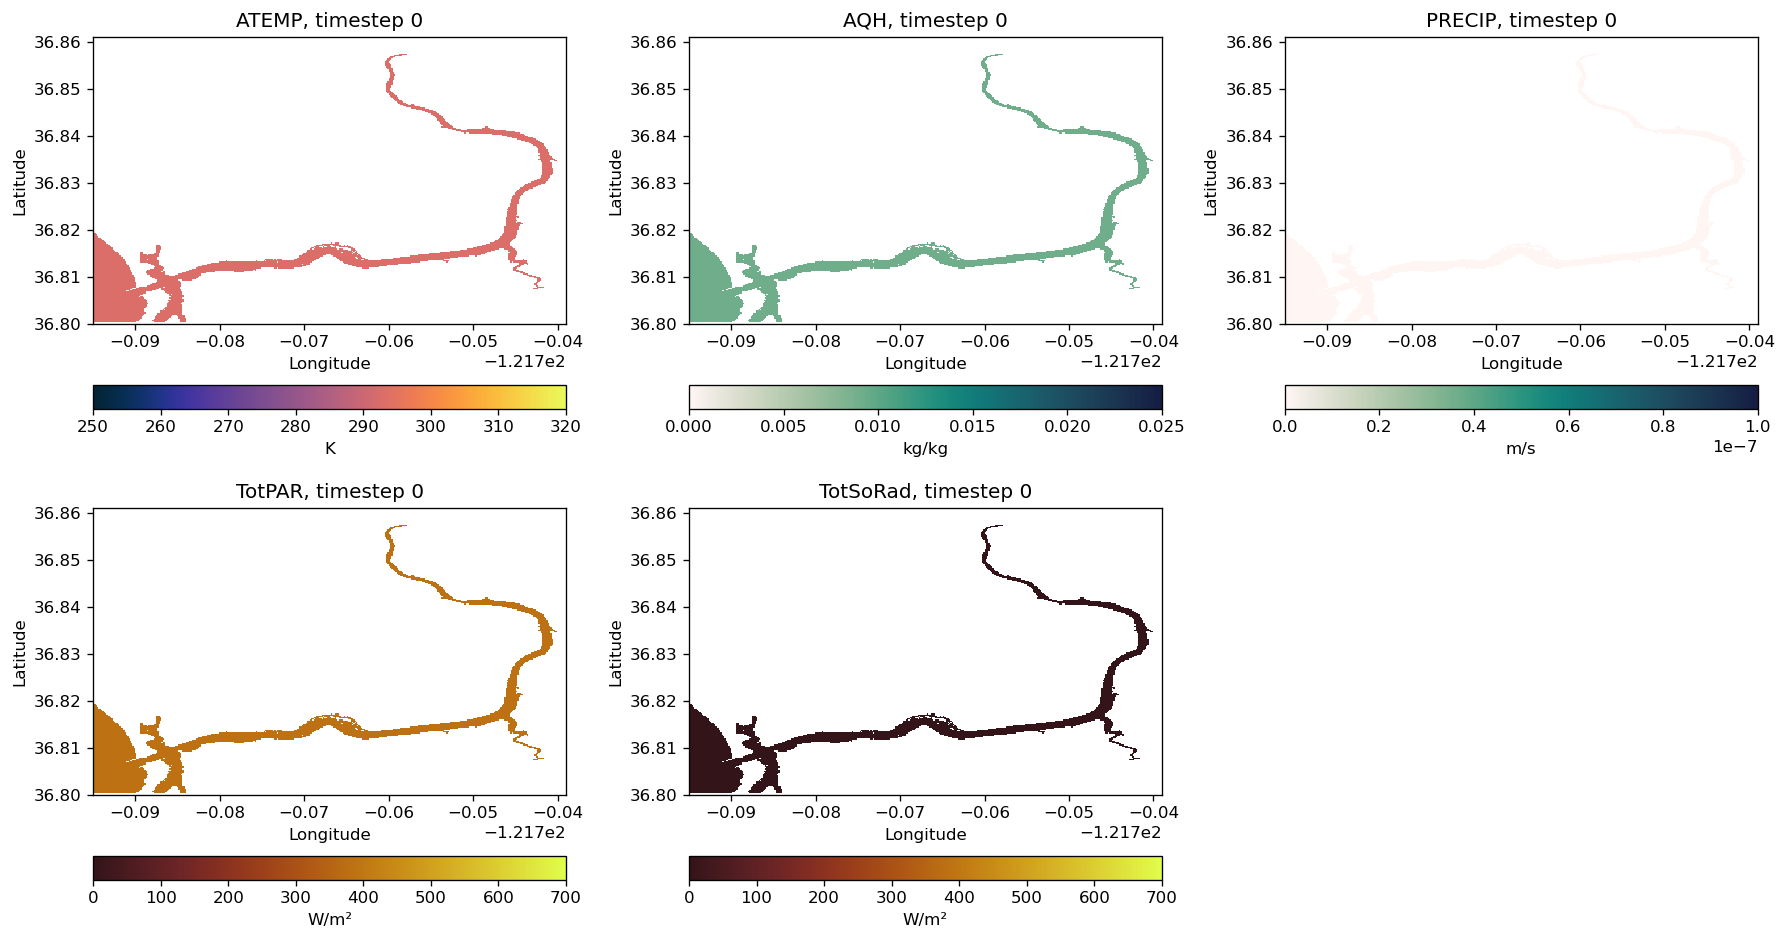

In [43]:
# -----------------------------
# Plot non-wind EXF fields
# -----------------------------

timestep = 0

fields_to_plot = ["ATEMP", "AQH", "PRECIP", "TotPAR", "TotSoRad"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=120)
axes = axes.ravel()

for ax, field in zip(axes, fields_to_plot):
    file_path = os.path.join(exf_output_dir, f"{field}_{year}")

    arr = np.fromfile(file_path, dtype=">f4").reshape((ntime, Ny, Nx))
    grid = arr[timestep, :, :]

    # Mask land for plotting
    grid_plot = np.ma.masked_where(mask2d == 0, grid)

    vmin, vmax, cmap, units = plot_meta[field]

    cmap_use = plt.get_cmap(cmap).copy() if isinstance(cmap, str) else cmap
    try:
        cmap_use = cmap_use.copy()
        cmap_use.set_bad("white")
    except Exception:
        pass

    im = ax.pcolormesh(
        XC,
        YC,
        grid_plot,
        shading="auto",
        cmap=cmap_use,
        vmin=vmin,
        vmax=vmax
    )

    fig.colorbar(im, ax=ax, orientation="horizontal", label=units)
    ax.set_title(f"{field}, timestep {timestep}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

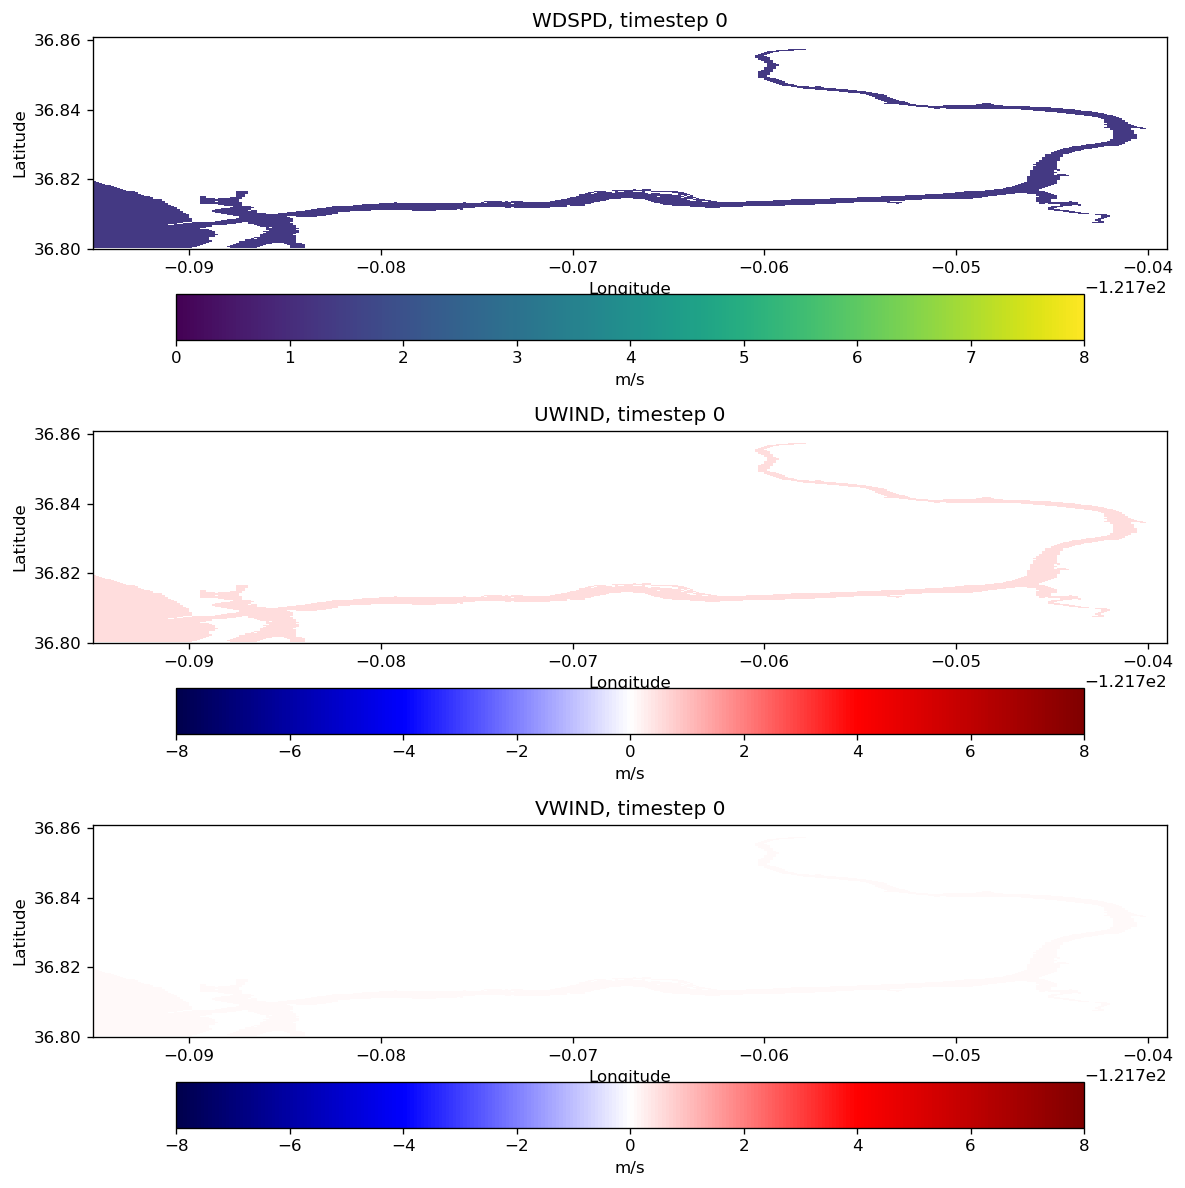

In [44]:
# -----------------------------
# Plot wind EXF fields
# -----------------------------

timestep = 0

wind_fields = ["WDSPD", "UWIND", "VWIND"]

fig, axes = plt.subplots(3, 1, figsize=(10, 10), dpi=120)

for ax, field in zip(axes, wind_fields):
    file_path = os.path.join(exf_output_dir, f"{field}_{year_wind}")

    arr = np.fromfile(file_path, dtype=">f4").reshape((ntime_wind, Ny, Nx))
    grid = arr[timestep, :, :]

    grid_plot = np.ma.masked_where(mask2d == 0, grid)

    vmin, vmax, cmap, units = plot_meta[field]

    cmap_use = plt.get_cmap(cmap).copy() if isinstance(cmap, str) else cmap
    try:
        cmap_use = cmap_use.copy()
        cmap_use.set_bad("white")
    except Exception:
        pass

    im = ax.pcolormesh(
        XC,
        YC,
        grid_plot,
        shading="auto",
        cmap=cmap_use,
        vmin=vmin,
        vmax=vmax
    )

    fig.colorbar(im, ax=ax, orientation="horizontal", label=units)
    ax.set_title(f"{field}, timestep {timestep}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [27]:
# -----------------------------
# Final EXF file check
# -----------------------------

files_to_check = {
    "ATEMP_2024": Ny * Nx,
    "AQH_2024": Ny * Nx,
    "PRECIP_2024": Ny * Nx,
    "TotPAR_2024": Ny * Nx,
    "TotSoRad_2024": Ny * Nx,
    "WDSPD_2024": Ny * Nx,
    "UWIND_2024": Ny * Nx,
    "VWIND_2024": Ny * Nx,
}

for fname, single_step_size in files_to_check.items():
    path = os.path.join(exf_output_dir, fname)

    if not os.path.exists(path):
        print(f"MISSING: {path}")
        continue

    nvals = os.path.getsize(path) // np.dtype(">f4").itemsize
    nt = nvals / single_step_size

    arr = np.fromfile(path, dtype=">f4")

    print(
        f"{fname:15s}",
        f"values={nvals:10d}",
        f"expected per timestep={single_step_size:8d}",
        f"nt={nt}",
        f"nan={np.isnan(arr).sum()}",
        f"min={np.nanmin(arr):.6g}",
        f"max={np.nanmax(arr):.6g}"
    )

ATEMP_2024      values=  31622400 expected per timestep=   86400 nt=366.0 nan=0 min=250 max=293.055
AQH_2024        values=  31622400 expected per timestep=   86400 nt=366.0 nan=0 min=0 max=0.0121615
PRECIP_2024     values=  31622400 expected per timestep=   86400 nt=366.0 nan=0 min=0 max=6.77566e-09
TotPAR_2024     values=  31622400 expected per timestep=   86400 nt=366.0 nan=0 min=0 max=688.904
TotSoRad_2024   values=  31622400 expected per timestep=   86400 nt=366.0 nan=0 min=0 max=0
WDSPD_2024      values=  31622400 expected per timestep=   86400 nt=366.0 nan=0 min=0 max=6.54792
UWIND_2024      values=  31622400 expected per timestep=   86400 nt=366.0 nan=0 min=-4.41278 max=4.29911
VWIND_2024      values=  31622400 expected per timestep=   86400 nt=366.0 nan=0 min=-2.23202 max=5.93367


## Notes on EXF file preparation

The EXF files are created by applying daily atmospheric observations uniformly over all wet model cells and setting land cells to zero. The wet mask is derived from the final cleaned MITgcm bathymetry, where water cells have negative depth and land cells are zero.

Relative humidity was converted to specific humidity because MITgcm's `aqhfile` expects atmospheric specific humidity. Air temperature was converted from degrees Celsius to Kelvin for `ATEMP`. Precipitation was converted from mm/day to m/s before saving as `PRECIP`.

All files are saved as big-endian 32-bit binary files with shape:

`(time, Ny, Nx) = (366, 240, 360)`.